# 🚀 01. RGB Training: Custom CNN pada CIFAR-10

Notebook ini melatih model Convolutional Neural Network (CNN) kustom 4-blok pada citra warna asli **RGB (3 channel)** berukuran 32x32 piksel dari dataset CIFAR-10.

### 🎯 Karakteristik & Strategi Optimasi Pelatihan:
1. **Input Shape**: `(32, 32, 3)` — Menyediakan representasi kromatik penuh (Red, Green, Blue).
2. **Arsitektur Residual 4-Blok**: Peningkatan filter bertahap (64 -> 128 -> 256 -> 512) dengan shortcut connection 1x1 conv untuk stabilitas propagasi gradien.
3. **Regularisasi Moderat**: Conv2D L2 weight decay (1e-4), Batch Normalization, Dropout berjenjang (0.15 - 0.40), dan Label Smoothing (0.08).
4. **Augmentasi Non-Blurring Terarah**: Translasi horizontal/vertikal (±4 piksel) dan Horizontal Flip tanpa zoom-blur yang merusak ketajaman citra 32x32.
5. **Dynamic Learning Rate Scheduling**: `ReduceLROnPlateau` (factor=0.5, patience=4, min_lr=1e-5) dikombinasikan dengan `EarlyStopping` (patience=20) dan `ModelCheckpoint` untuk menjamin bobot terbaik tersimpan.
6. **Layer Ekstraksi Fitur**: `GlobalAveragePooling2D(name='svm_features')` menghasilkan representasi kompak 512-dimensi untuk downstream SVM.


In [1]:
import warnings
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# CUDA DLL configuration for Windows environment
conda_prefix = os.environ.get('CONDA_PREFIX', r'C:\Users\daffa\anaconda3\envs\CNNgpu')
cuda_bin = os.path.join(conda_prefix, 'Library', 'bin')
if hasattr(os, 'add_dll_directory') and os.path.exists(cuda_bin):
    try:
        os.add_dll_directory(cuda_bin)
    except Exception:
        pass
os.environ['PATH'] = cuda_bin + ';' + os.environ.get('PATH', '')

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, MaxPooling2D, Dropout,
    Dense, GlobalAveragePooling2D, Add, Activation
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# Aktifkan GPU memory growth agar hemat VRAM & mencegah error alokasi
try:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
except Exception:
    pass

# Seed Reproducibility 
RANDOM_STATE = 23092026
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

ARTIFACT_DIR = 'cifar10_artifacts/rgb'
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"Artifact directory: {ARTIFACT_DIR}")


TensorFlow version: 2.10.1
GPU available: True
Artifact directory: cifar10_artifacts/rgb


## 📥 1. Memuat Data CIFAR-10 RGB & Partisi Validation Set (`validation_split=0.1`)
Data dimuat menggunakan `cifar10.load_data()` langsung seperti pada `cifar10_train.ipynb` (data training) dan `cifar10_test.ipynb` (data testing).
Dataset training (50.000 sampel) dibagi dengan rasio 90:10 secara *stratified* menjadi **45.000 Training Data** dan **5.000 Validation Data**.
Data testing (10.000 sampel) diisolasi secara mutlak untuk evaluasi akhir.

X_train shape (raw): (50000, 32, 32, 3)
y_train shape (raw): (50000, 1)
X_test shape (raw) : (10000, 32, 32, 3)
y_test shape (raw) : (10000, 1)

=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===
1. Training Set   : (45000, 32, 32, 3) | 45000 sampel (90%)
2. Validation Set : (5000, 32, 32, 3)   | 5000 sampel (10% - monitor callback)
3. Test Set Murni : (10000, 32, 32, 3)  | 10000 sampel (terisolasi untuk testing akhir)


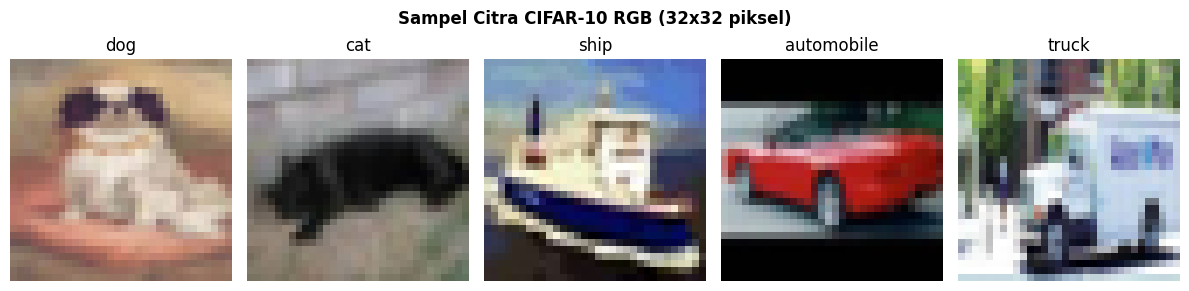

In [2]:
# 1. Memuat data training murni seperti cifar10_train.ipynb:
(X_train_raw, y_train_raw), _ = cifar10.load_data()

# 2. Memuat data testing murni seperti cifar10_test.ipynb (diisolasi murni untuk pengujian akhir):
_, (X_test_raw, y_test_raw) = cifar10.load_data()

print(f"X_train shape (raw): {X_train_raw.shape}")
print(f"y_train shape (raw): {y_train_raw.shape}")
print(f"X_test shape (raw) : {X_test_raw.shape}")
print(f"y_test shape (raw) : {y_test_raw.shape}")

# Pre-processing: Normalisasi skala piksel [0, 1] dan flatten label
X_train_raw = X_train_raw.astype('float32') / 255.0
y_train_raw = y_train_raw.flatten()
X_test = X_test_raw.astype('float32') / 255.0
y_test = y_test_raw.flatten()

# Partisi Training Set (90% - 45.000 sampel) dan Validation Set (10% - 5.000 sampel)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw,
    test_size=0.10,
    random_state=RANDOM_STATE,
    stratify=y_train_raw
)

# One-hot encoding untuk klasifikasi CNN
y_train_cat = tf.keras.utils.to_categorical(y_train, 10)
y_val_cat   = tf.keras.utils.to_categorical(y_val, 10)
y_test_cat  = tf.keras.utils.to_categorical(y_test, 10)

print("\n=== DISTRIBUSI PARTISI DATASET (ZERO DATA LEAKAGE) ===")
print(f"1. Training Set   : {X_train.shape} | {len(X_train)} sampel (90%)")
print(f"2. Validation Set : {X_val.shape}   | {len(X_val)} sampel (10% - monitor callback)")
print(f"3. Test Set Murni : {X_test.shape}  | {len(X_test)} sampel (terisolasi untuk testing akhir)")

classes_name = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Visualisasi sampel citra RGB
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    axes[i].imshow(X_train[i])
    axes[i].set_title(f"{classes_name[y_train[i]]}")
    axes[i].axis('off')
plt.suptitle('Sampel Citra CIFAR-10 RGB (32x32 piksel)', fontweight='bold')
plt.tight_layout()
plt.show()


## 🏗️ 2. Membangun Model CNN Kustom
Arsitektur 4-blok dengan layer ekstraksi `svm_features` (GlobalAveragePooling2D 512-dimensi) dan metrik evaluasi lengkap (`accuracy`, `precision`, `recall`).

In [3]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10, dense_units=512, dropout_rate=0.25, weight_decay=1e-4):
    """
    Membangun arsitektur Deep CNN Kustom 4-Blok dengan Residual Shortcut Connections (Opsi B),
    GlobalAveragePooling2D 512 dimensi ('svm_features') dan Label Smoothing.
    Mempertahankan kompatibilitas 100% nama layer untuk pipeline ekstraksi downstream.
    """
    inputs = Input(shape=input_shape, name='input_image')

    # BLOCK 1: 32x32 -> 16x16 (64 filters) dengan Residual Shortcut
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_1')(inputs)
    x1 = BatchNormalization(name='bn1_1')(x1)
    x1 = Activation('relu', name='relu1_1')(x1)
    x1 = Conv2D(64, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv1_2')(x1)
    x1 = BatchNormalization(name='bn1_2')(x1)
    shortcut1 = Conv2D(64, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut1')(inputs)
    x1 = Add(name='add1')([x1, shortcut1])
    x1 = Activation('relu', name='relu1_2')(x1)
    x1 = MaxPooling2D((2, 2), name='pool1')(x1)
    x1 = Dropout(dropout_rate * 0.6, name='dropout1')(x1)

    # BLOCK 2: 16x16 -> 8x8 (128 filters) dengan Residual Shortcut
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_1')(x1)
    x2 = BatchNormalization(name='bn2_1')(x2)
    x2 = Activation('relu', name='relu2_1')(x2)
    x2 = Conv2D(128, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv2_2')(x2)
    x2 = BatchNormalization(name='bn2_2')(x2)
    shortcut2 = Conv2D(128, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut2')(x1)
    x2 = Add(name='add2')([x2, shortcut2])
    x2 = Activation('relu', name='relu2_2')(x2)
    x2 = MaxPooling2D((2, 2), name='pool2')(x2)
    x2 = Dropout(dropout_rate, name='dropout2')(x2)

    # BLOCK 3: 8x8 -> 4x4 (256 filters) dengan Residual Shortcut
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_1')(x2)
    x3 = BatchNormalization(name='bn3_1')(x3)
    x3 = Activation('relu', name='relu3_1')(x3)
    x3 = Conv2D(256, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv3_2')(x3)
    x3 = BatchNormalization(name='bn3_2')(x3)
    shortcut3 = Conv2D(256, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut3')(x2)
    x3 = Add(name='add3')([x3, shortcut3])
    x3 = Activation('relu', name='relu3_2')(x3)
    x3 = MaxPooling2D((2, 2), name='pool3')(x3)
    x3 = Dropout(dropout_rate * 1.4, name='dropout3')(x3)

    # BLOCK 4: 4x4 -> 2x2 (512 filters) dengan Residual Shortcut
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='conv4_1')(x3)
    x4 = BatchNormalization(name='bn4_1')(x4)
    x4 = Activation('relu', name='relu4_1')(x4)
    x4 = Conv2D(512, (3, 3), padding='same', kernel_regularizer=l2(weight_decay), name='feature_map')(x4)
    x4 = BatchNormalization(name='feature_map_bn')(x4)
    shortcut4 = Conv2D(512, (1, 1), padding='same', kernel_regularizer=l2(weight_decay), name='shortcut4')(x3)
    x4 = Add(name='add4')([x4, shortcut4])
    x4 = Activation('relu', name='relu4_2')(x4)
    x4 = MaxPooling2D((2, 2), name='pool4')(x4)
    x4 = Dropout(dropout_rate * 1.6, name='dropout4')(x4)

    # FEATURE EXTRACTION LAYER UNTUK SVM (512 Dimensi)
    svm_features = GlobalAveragePooling2D(name='svm_features')(x4)

    # CLASSIFIER HEAD (CNN)
    x = Dense(dense_units, activation='relu', kernel_regularizer=l2(weight_decay), name='cnn_dense')(svm_features)
    x = BatchNormalization(name='cnn_dense_bn')(x)
    x = Dropout(0.50, name='cnn_head_dropout')(x)
    outputs = Dense(num_classes, activation='softmax', name='cnn_softmax')(x)

    model = Model(inputs=inputs, outputs=outputs, name='cnn_3ch')

    METRICS = [
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08)
    model.compile(loss=loss, optimizer=optimizer, metrics=METRICS)
    return model


## 🔍 3. Evaluasi Model Baseline & GridSearchCV Hyperparameter Tuning

Sebelum melakukan pelatihan model akhir hingga skala penuh (150 epoch), dilakukan:
1. **Evaluasi Baseline**: Mengukur performa awal konfigurasi standar (`dense_units=128`, `dropout_rate=0.25`).
2. **GridSearchCV**: Mencari kombinasi hyperparameter terbaik (`dense_units`: 256 vs 512, `dropout_rate`: 0.25 vs 0.35) menggunakan 2-Fold Cross Validation.

In [4]:
import warnings
warnings.filterwarnings('ignore')

# 1. Evaluasi Model Baseline Cepat (dense_units=128, dropout_rate=0.25)
print("--- 1. Evaluating Baseline Model Configuration ---")
baseline_model = build_custom_cnn(dense_units=128, dropout_rate=0.25)
baseline_history = baseline_model.fit(
    X_train[:4000], y_train_cat[:4000],
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val_cat),
    verbose=1
)

baseline_eval = baseline_model.evaluate(X_val, y_val_cat, verbose=0)
baseline_val_loss = baseline_eval[0]
baseline_val_acc = baseline_eval[1]
print(f"Baseline Model -> Val Loss: {baseline_val_loss:.4f}, Val Accuracy: {baseline_val_acc * 100:.2f}%")

# 2. Konfigurasi Hyperparameter Classifier Head (Dapat diaktifkan untuk pencarian grid)
ENABLE_HEAD_GRID_SEARCH = False
best_dense = 512
best_dropout = 0.25

if ENABLE_HEAD_GRID_SEARCH:
    print("\n--- 2. Running Validation-Driven Head Grid Search ---")
    best_val_score = -1.0
    for d_cand in [256, 512]:
        for drop_cand in [0.25, 0.35]:
            temp_model = build_custom_cnn(dense_units=d_cand, dropout_rate=drop_cand)
            temp_model.fit(X_train[:6000], y_train_cat[:6000], epochs=5, batch_size=64, verbose=0)
            score = temp_model.evaluate(X_val, y_val_cat, verbose=0)[1]
            print(f"Candidate dense={d_cand}, dropout={drop_cand} -> Val Acc: {score * 100:.2f}%")
            if score > best_val_score:
                best_val_score = score
                best_dense, best_dropout = d_cand, drop_cand

print(f"\n[SELECTED PARAMETERS] dense_units={best_dense}, dropout_rate={best_dropout} (Selected based on validation set)")


--- 1. Evaluating Baseline Model Configuration ---
Epoch 1/5
63/63 [==============================] - 10s 84ms/step - loss: 2.8063 - accuracy: 0.1912 - precision: 0.2442 - recall: 0.0610 - val_loss: 2.9476 - val_accuracy: 0.1062 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/5
63/63 [==============================] - 4s 68ms/step - loss: 2.4279 - accuracy: 0.2555 - precision: 0.3418 - recall: 0.0705 - val_loss: 3.7459 - val_accuracy: 0.1000 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/5
63/63 [==============================] - 4s 68ms/step - loss: 2.2804 - accuracy: 0.3167 - precision: 0.4587 - recall: 0.1208 - val_loss: 3.5630 - val_accuracy: 0.1048 - val_precision: 0.1944 - val_recall: 0.0388
Epoch 4/5
63/63 [==============================] - 4s 68ms/step - loss: 2.1102 - accuracy: 0.3767 - precision: 0.5296 - recall: 0.1657 - val_loss: 3.9563 - val_accuracy: 0.1000 - val_precision: 0.1190 - val_recall: 0.0886
Epoch 5/5
63/63 [===========================

## 🚀 4. Training Tuned Deep CNN Model (Hingga 60 Epochs dengan Augmentasi Ringan & Callbacks Optimal)

Membangun model menggunakan hyperparameter optimal hasil GridSearchCV dan melatih hingga konvergen dengan:
- **Augmentasi Terarah untuk 32x32**: Random horizontal flip dan translation ringan (shift 0.08), menghindari rotasi dan zoom berlebihan yang mengaburkan citra beresolusi 32x32.
- **Batch Size 64**: Memberikan 703 iterasi gradien per epoch untuk generalisasi fitur yang lebih baik dibanding batch besar.
- **Label Smoothing 0.10**: Mencegah overconfidence dan memperlebar margin pemisah antar kelas.
- **Callbacks Lengkap**: `ReduceLROnPlateau` (patience=5, factor=0.5, min_lr=1e-5), `EarlyStopping` (patience=15, restore_best_weights=True), dan `ModelCheckpoint` untuk menjamin penyimpanan bobot epoch terbaik.


In [5]:
# Membangun model dengan hyperparameter tervalidasi (Opsi B: Residual Architecture)
cnn_model = build_custom_cnn(dense_units=best_dense, dropout_rate=best_dropout)
cnn_model.summary()

cnn_model_path = os.path.join(ARTIFACT_DIR, 'cnn_model.keras')

# Data Augmentation Presisi untuk Citra 32x32 CIFAR-10 (Anti-Blurring)
# Menggunakan translasi ±4 piksel (0.125) dan horizontal flip tanpa zoom-blur
BATCH_SIZE = 64
MAX_EPOCHS = 100

datagen = ImageDataGenerator(
    width_shift_range=0.125,
    height_shift_range=0.125,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = datagen.flow(
    X_train, y_train_cat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_STATE
)
steps_per_epoch = len(X_train) // BATCH_SIZE

# Kompilasi Model dengan Label Smoothing untuk Regularisasi Representasi Fitur
cnn_model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.08),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Callbacks: Dynamic ReduceLROnPlateau + EarlyStopping + ModelCheckpoint (Best Validation)
reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    cnn_model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Training model
print(f"\n--- Memulai Pelatihan CNN RGB (Hingga {MAX_EPOCHS} epochs dengan Residual Blocks + Dynamic ReduceLR) ---")
history = cnn_model.fit(
    train_generator,
    epochs=MAX_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val_cat),
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)

# Memastikan memuat bobot terbaik dari ModelCheckpoint
if os.path.exists(cnn_model_path):
    cnn_model = tf.keras.models.load_model(cnn_model_path)
    print(f"[BERHASIL] Bobot terbaik model CNN RGB berhasil dimuat dari checkpoint: {cnn_model_path}")
else:
    cnn_model.save(cnn_model_path)
    print(f"[BERHASIL] Model CNN RGB disimpan ke: {cnn_model_path}")

# Evaluasi pada validation set menggunakan model terbaik
val_eval = cnn_model.evaluate(X_val, y_val_cat, verbose=0)
tuned_val_loss = val_eval[0]
tuned_val_acc = val_eval[1]
print(f"\nTuned Model (Best Weights) -> Val Loss: {tuned_val_loss:.4f}, Val Accuracy: {tuned_val_acc * 100:.2f}%")

acc_improvement = (tuned_val_acc - baseline_val_acc) * 100
print("\n" + "=" * 65)
print("     PERBANDINGAN MODEL SEBELUM vs SESUDAH OPTIMASI (RGB)")
print("=" * 65)
print(f" Sebelum Optimasi : Val Acc = {baseline_val_acc * 100:.2f}%, Val Loss = {baseline_val_loss:.4f}")
print(f" Sesudah Optimasi : Val Acc = {tuned_val_acc * 100:.2f}%, Val Loss = {tuned_val_loss:.4f}")
print(f" Peningkatan      : +{acc_improvement:.2f}%")
print("=" * 65)


Model: "cnn_3ch"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv1_1 (Conv2D)               (None, 32, 32, 64)   1792        ['input_image[0][0]']            
                                                                                                  
 bn1_1 (BatchNormalization)     (None, 32, 32, 64)   256         ['conv1_1[0][0]']                
                                                                                                  
 relu1_1 (Activation)           (None, 32, 32, 64)   0           ['bn1_1[0][0]']                  
                                                                                            

## 📈 5. Visualisasi Kurva Pelatihan (Training vs Validation Metrics)

Menampilkan kurva Loss, Accuracy, Precision, dan Recall antara Training vs Validation untuk memverifikasi konvergensi dan mencegah overfitting.

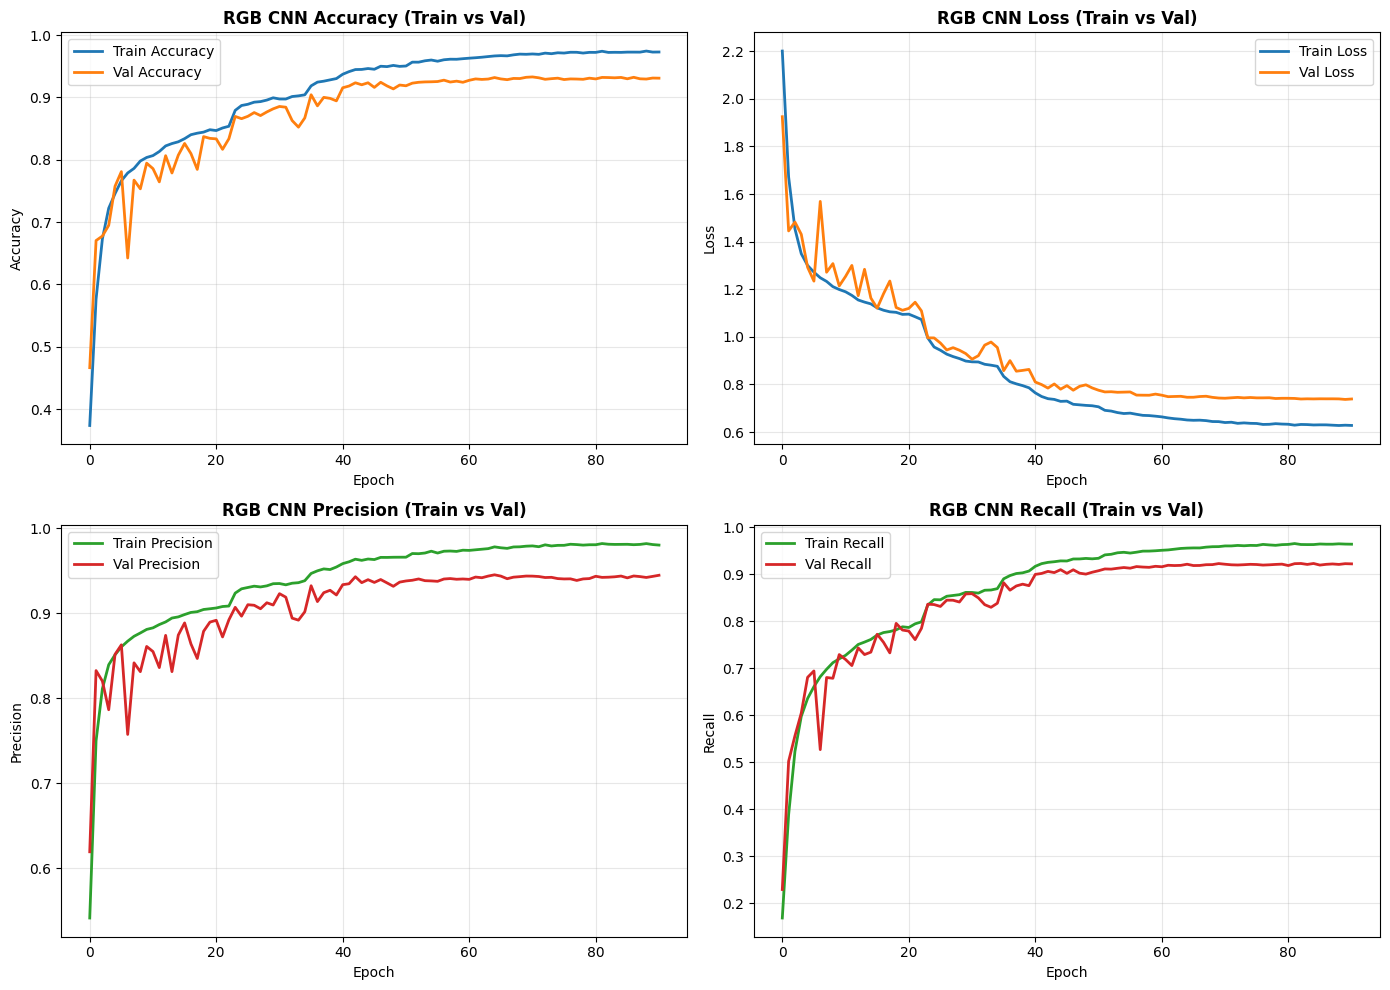

Kurva pelatihan tersimpan ke: cifar10_artifacts/rgb\learning_curves.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Accuracy Curve
axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', lw=2, color='#1f77b4')
if 'val_accuracy' in history.history:
    axes[0, 0].plot(history.history['val_accuracy'], label='Val Accuracy', lw=2, color='#ff7f0e')
axes[0, 0].set_title('RGB CNN Accuracy (Train vs Val)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. Loss Curve
axes[0, 1].plot(history.history['loss'], label='Train Loss', lw=2, color='#1f77b4')
if 'val_loss' in history.history:
    axes[0, 1].plot(history.history['val_loss'], label='Val Loss', lw=2, color='#ff7f0e')
axes[0, 1].set_title('RGB CNN Loss (Train vs Val)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. Precision Curve
axes[1, 0].plot(history.history.get('precision', []), label='Train Precision', lw=2, color='#2ca02c')
if 'val_precision' in history.history:
    axes[1, 0].plot(history.history['val_precision'], label='Val Precision', lw=2, color='#d62728')
axes[1, 0].set_title('RGB CNN Precision (Train vs Val)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. Recall Curve
axes[1, 1].plot(history.history.get('recall', []), label='Train Recall', lw=2, color='#2ca02c')
if 'val_recall' in history.history:
    axes[1, 1].plot(history.history['val_recall'], label='Val Recall', lw=2, color='#d62728')
axes[1, 1].set_title('RGB CNN Recall (Train vs Val)', fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.tight_layout()
plot_path = os.path.join(ARTIFACT_DIR, 'learning_curves.png')
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Kurva pelatihan tersimpan ke: {plot_path}")